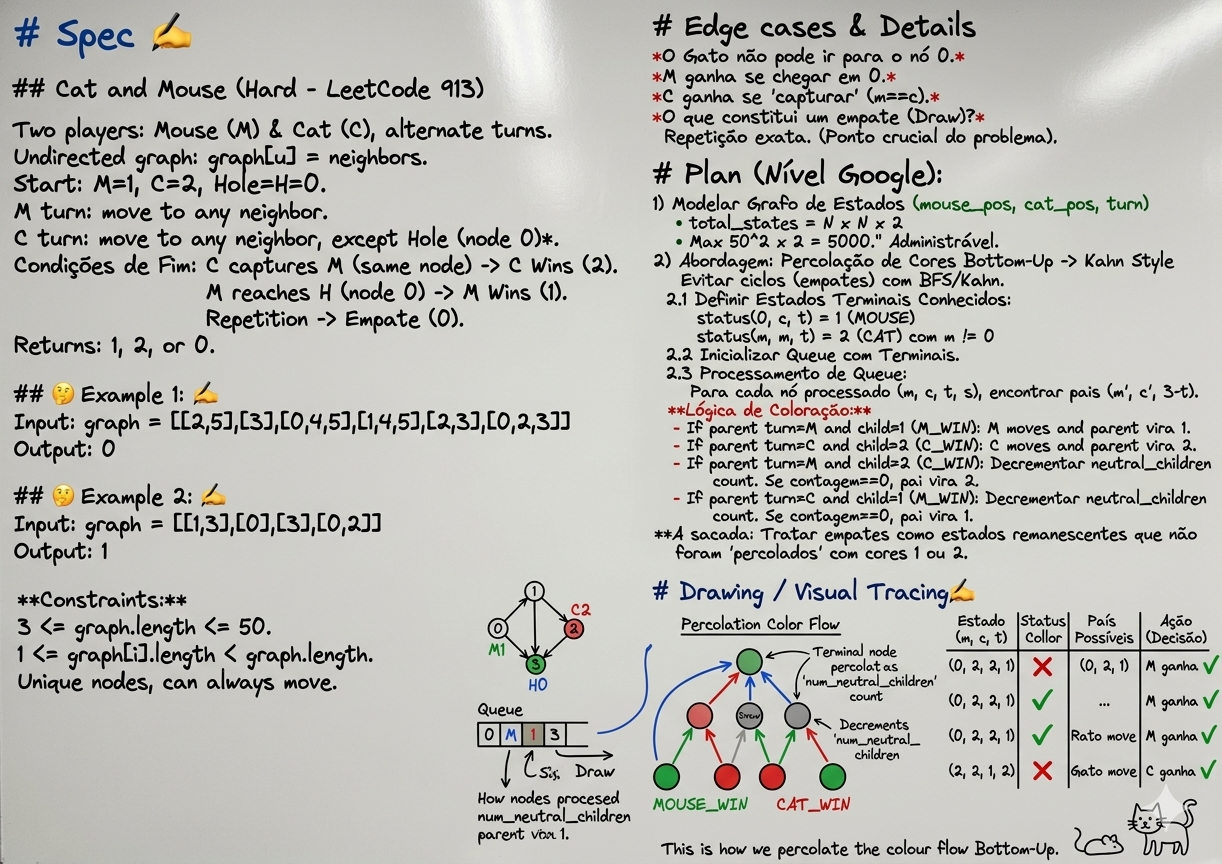

In [ ]:
from collections import deque

class Solution:
    def catMouseGame(self, graph: list[list[int]]) -> int:
        n = len(graph)
        # Estados: (mouse_pos, cat_pos, turn) 
        # turn: 1 para Rato, 2 para Gato
        MOUSE, CAT, DRAW = 1, 2, 0
        
        # 1. Tabela de Estados e Graus de Saída (Out-degree)
        # status[m][c][t] armazena quem ganha naquele estado
        status = [[[DRAW] * 3 for _ in range(n)] for _ in range(n)]
        
        # degree[m][c][t] armazena quantos movimentos possíveis restam
        degree = [[[0] * 3 for _ in range(n)] for _ in range(n)]
        
        for m in range(n):
            for c in range(n):
                degree[m][c][1] = len(graph[m])
                # O Gato não pode se mover para o buraco (nó 0)
                degree[m][c][2] = len([v for v in graph[c] if v != 0])

        # 2. Inicializar Fila com Estados Terminais Conhecidos
        queue = deque()
        
        for i in range(1, n):
            # Se o Rato está no buraco (0), Rato venceu
            for t in [1, 2]:
                status[0][i][t] = MOUSE
                queue.append((0, i, t, MOUSE))
                
                # Se o Gato captura o Rato (m == c), Gato venceu
                status[i][i][t] = CAT
                queue.append((i, i, t, CAT))

        # 3. Função Auxiliar para encontrar Pais (Estados anteriores)
        def get_parents(m, c, t):
            parents = []
            if t == 1: # Turno atual é do Rato, então o anterior foi do Gato
                for prev_c in graph[c]:
                    if prev_c != 0: # Gato nunca veio do buraco
                        parents.append((m, prev_c, 2))
            else: # Turno atual é do Gato, então o anterior foi do Rato
                for prev_m in graph[m]:
                    parents.append((prev_m, c, 1))
            return parents

        # 4. Percolação (Kahn's Style / Bottom-up BFS)
        while queue:
            m, c, t, winner = queue.popleft()
            
            for pm, pc, pt in get_parents(m, c, t):
                if status[pm][pc][pt] == DRAW:
                    # Lógica de Coloração Imediata (Win condition)
                    # Se for a vez do jogador e ele pode mover para um estado onde ele ganha
                    if pt == winner:
                        status[pm][pc][pt] = winner
                        queue.append((pm, pc, pt, winner))
                    
                    # Lógica de Coloração Eventual (Loss condition)
                    # Se todos os caminhos possíveis levam à vitória do oponente
                    else:
                        degree[pm][pc][pt] -= 1
                        if degree[pm][pc][pt] == 0:
                            status[pm][pc][pt] = winner
                            queue.append((pm, pc, pt, winner))

        # O jogo começa com Rato em 1, Gato em 2 e turno do Rato (1)
        return status[1][2][1]